# Лабораторная работа №1
## Разведочный анализ данных на примере датасета Iris

**Цель работы:** Изучение методов визуализации данных и проведение разведочного анализа на классическом наборе данных ирисов Фишера.

## Описание набора данных Iris

**Источник данных:** Набор данных Iris (Ирисы Фишера) был представлен британским статистиком и биологом Рональдом Фишером в 1936 году. Он стал классическим примером для задач классификации в машинном обучении.

**Характеристики датасета:**
- **Количество образцов:** 150 цветков
- **Количество классов:** 3 вида ирисов (по 50 образцов каждого)
- **Признаки (все в сантиметрах):**
  - Длина чашелистика (sepal length)
  - Ширина чашелистика (sepal width)
  - Длина лепестка (petal length)
  - Ширина лепестка (petal width)
- **Целевая переменная:** Вид ириса (setosa, versicolor, virginica)

**Особенности:** Датасет не содержит пропущенных значений, что делает его идеальным для первой лабораторной работы.

In [5]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

# Настройка отображения графиков
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Загрузка датасета Iris
iris = load_iris()

# Создание DataFrame для удобного анализа
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map({i: name for i, name in enumerate(iris.target_names)})

print("Датасет успешно загружен!")
print(f"Размер датасета: {df.shape}")

Датасет успешно загружен!
Размер датасета: (150, 6)


## Основные характеристики датасета

In [12]:
# 1. Первые 5 строк датасета
print("Первые 5 строк датасета:")
df.head()

Первые 5 строк датасета:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [15]:
# 2. Информация о данных (типы, количество непустых значений)
print("\nИнформация о датасете:")
df.dtypes


Информация о датасете:


sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
species               object
dtype: object

In [17]:
# 3. Размер датасета 150 строк и 6 колонок
df.shape

(150, 6)

In [18]:
# 4. Проверка на пропуски
print("\nКоличество пропущенных значений:")
df.isnull().sum()


Количество пропущенных значений:


sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

In [19]:
# 5. Описательные статистики
print("\nОписательные статистики:")
df.describe()


Описательные статистики:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [21]:
# 6. Распределение целевой переменной
print("\nРаспределение по видам ирисов:")
df['species'].value_counts()
# Ожидаем по 50 образцов каждого вида


Распределение по видам ирисов:


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

## Визуальный анализ данных

В этом разделе мы построим различные графики для понимания распределения признаков и взаимосвязей между ними.

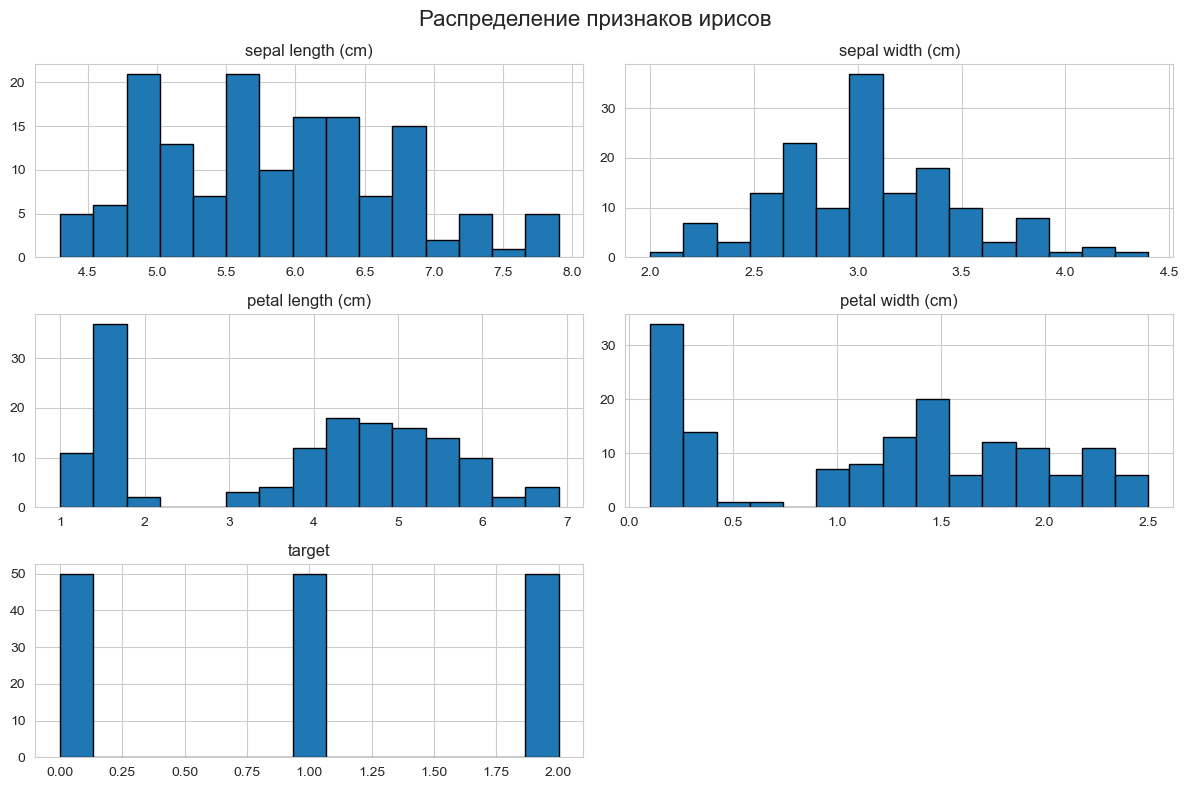

In [22]:
# Гистограммы для всех числовых признаков
df.hist(bins=15, figsize=(12, 8), edgecolor='black')
plt.suptitle('Распределение признаков ирисов', size=16)
plt.tight_layout()
plt.show()

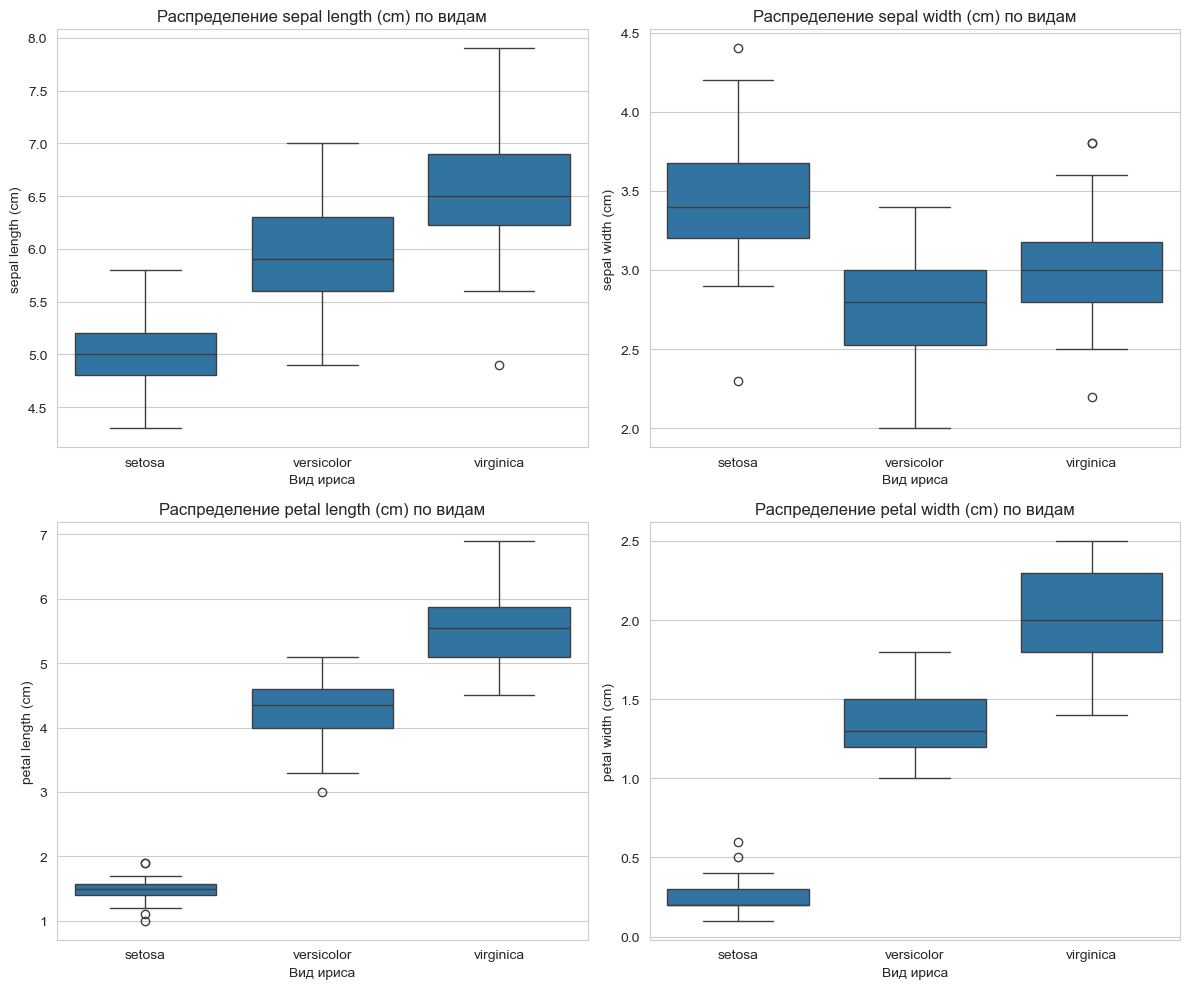

In [23]:
# Сравнение признаков по классам
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, feature in enumerate(iris.feature_names):
    sns.boxplot(x='species', y=feature, data=df, ax=axes[i])
    axes[i].set_title(f'Распределение {feature} по видам')
    axes[i].set_xlabel('Вид ириса')

plt.tight_layout()
plt.show()

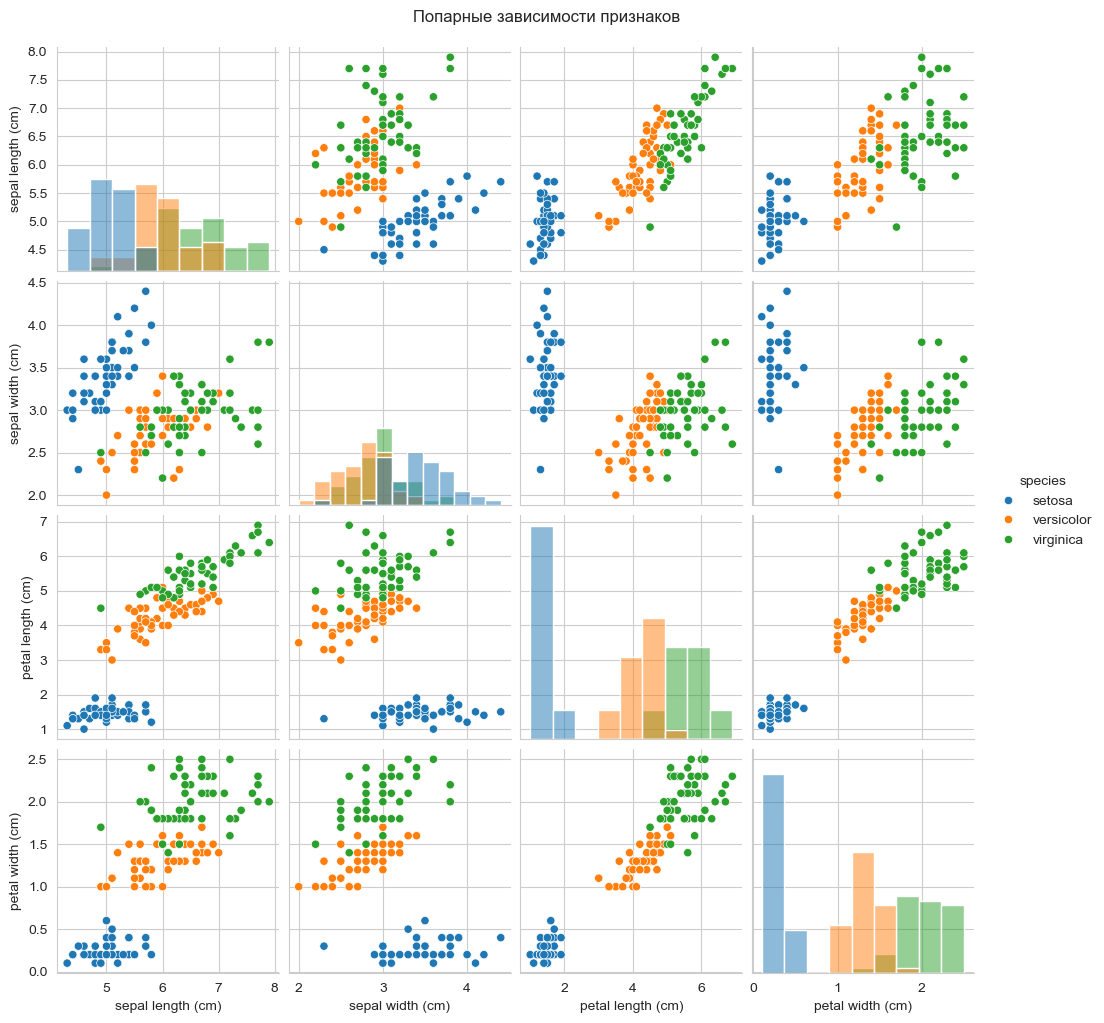

In [24]:
# Pairplot - один из самых информативных графиков для EDA
sns.pairplot(df, hue='species', vars=iris.feature_names, diag_kind='hist')
plt.suptitle('Попарные зависимости признаков', y=1.02)
plt.show()

## Анализ корреляции признаков

Корреляция показывает, насколько сильно связаны между собой различные признаки.

In [25]:
correlation_matrix = df[iris.feature_names].corr()

print("Матрица корреляции:")
correlation_matrix

Матрица корреляции:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


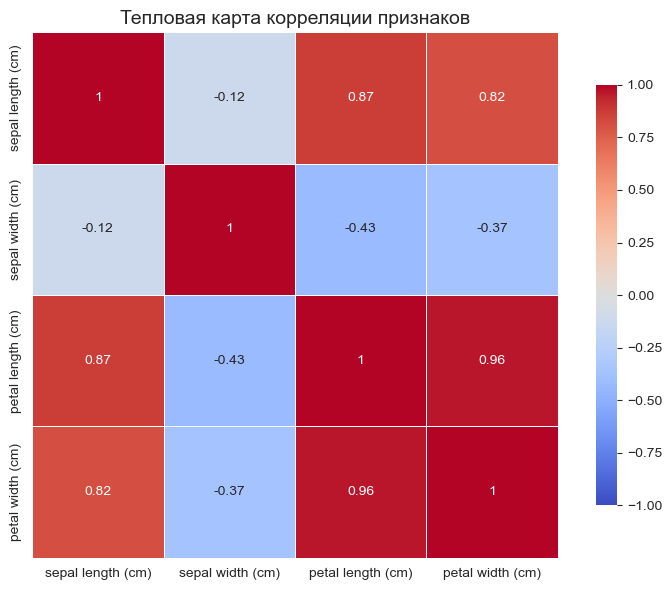


Наблюдения:
- Сильная положительная корреляция между длиной лепестка и шириной лепестка (~0.96)
- Также сильная корреляция между длиной лепестка и длиной чашелистика (~0.87)
- Ширина чашелистика слабо коррелирует с другими признаками
- Это объясняет, почему по лепесткам виды разделяются лучше, чем по чашелистикам



In [26]:
# Визуализация матрицы корреляции
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, 
            annot=True,           # отображать значения
            cmap='coolwarm',       # цветовая схема
            vmin=-1, vmax=1,       # границы значений корреляции
            square=True,           # квадратные ячейки
            linewidths=0.5,        
            cbar_kws={"shrink": 0.8})
plt.title('Тепловая карта корреляции признаков', size=14)
plt.tight_layout()
plt.show()

# Пояснение полученных результатов
print("""
Наблюдения:
- Сильная положительная корреляция между длиной лепестка и шириной лепестка (~0.96)
- Также сильная корреляция между длиной лепестка и длиной чашелистика (~0.87)
- Ширина чашелистика слабо коррелирует с другими признаками
- Это объясняет, почему по лепесткам виды разделяются лучше, чем по чашелистикам
""")

## Выводы по результатам разведочного анализа

В ходе выполнения лабораторной работы был проведен разведочный анализ данных (EDA) на наборе данных Iris. Основные результаты:

1. **Структура данных:** Датасет содержит 150 образцов, 4 признака и 3 класса целевой переменной. Пропуски данных отсутствуют.

2. **Распределение признаков:** 
   - Длина и ширина лепестка имеют явные различия между классами
   - Setosa хорошо отделяется от двух других видов по размерам лепестков
   - Versicolor и Virginica имеют некоторое пересечение, особенно по чашелистикам

3. **Корреляционный анализ:**
   - Наиболее сильная корреляция наблюдается между длиной лепестка и шириной лепестка (0.96)
   - Длина лепестка также сильно коррелирует с длиной чашелистика (0.87)
   - Это говорит о том, что для классификации достаточно использовать не все признаки

4. **Визуализация показала:**
   - Pairplot наглядно демонстрирует разделимость классов по различным комбинациям признаков
   - По лепесткам (petal) классы разделяются практически идеально
   - По чашелистикам (sepal) наблюдается значительное перекрытие между Versicolor и Virginica

Таким образом, проведенный анализ подтверждает, что датасет Iris хорошо подходит для задач классификации и позволяет наглядно продемонстрировать основные методы визуализации данных.